In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Dimensionality reduction and visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Clustering
from sklearn.cluster import KMeans, MiniBatchKMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# Evaluation metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Model persistence
import joblib
import pickle

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU Available: []


In [6]:
# Load the credit card dataset
df = pd.read_csv('CC GENERAL.csv')  # Replace with your file path

print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First 5 rows:")
print(df.head())
print("\n" + "="*80)
print("Dataset Information:")
print(df.info())
print("\n" + "="*80)
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*80)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*80)
print("Column Names:")
print(df.columns.tolist())


Dataset Shape: (8950, 18)

First 5 rows:
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.08333

In [7]:
# Store customer IDs separately
customer_ids = df['CUST_ID'].copy()

# Drop CUST_ID for modeling
df_model = df.drop('CUST_ID', axis=1)

print(f"Original dataset shape: {df_model.shape}")

# Handle missing values
print(f"\nMissing values before imputation:\n{df_model.isnull().sum()}")

# MINIMUM_PAYMENTS and CREDIT_LIMIT have missing values
# Use median imputation (robust to outliers)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_model),
    columns=df_model.columns
)

print(f"\nMissing values after imputation:\n{df_imputed.isnull().sum()}")

# Save imputer for production use
joblib.dump(imputer, 'imputer_model.pkl')
print("\n✓ Imputer saved as 'imputer_model.pkl'")


Original dataset shape: (8950, 17)

Missing values before imputation:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Missing values after imputation:
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE 

In [8]:
# Create derived features based on domain knowledge
df_features = df_imputed.copy()

# 1. Balance to Credit Limit Ratio
df_features['BALANCE_CREDIT_RATIO'] = df_features['BALANCE'] / (df_features['CREDIT_LIMIT'] + 1)

# 2. Purchase to Payment Ratio
df_features['PURCHASES_PAYMENT_RATIO'] = df_features['PURCHASES'] / (df_features['PAYMENTS'] + 1)

# 3. Cash Advance to Purchase Ratio
df_features['CASH_ADV_PURCHASE_RATIO'] = df_features['CASH_ADVANCE'] / (df_features['PURCHASES'] + 1)

# 4. Average Purchase per Transaction
df_features['AVG_PURCHASE_TRX'] = df_features['PURCHASES'] / (df_features['PURCHASES_TRX'] + 1)

# 5. Average Cash Advance per Transaction
df_features['AVG_CASH_ADV_TRX'] = df_features['CASH_ADVANCE'] / (df_features['CASH_ADVANCE_TRX'] + 1)

# 6. Monthly Average Purchase
df_features['MONTHLY_AVG_PURCHASES'] = df_features['PURCHASES'] / 12

# 7. Monthly Average Cash Advance
df_features['MONTHLY_AVG_CASH_ADV'] = df_features['CASH_ADVANCE'] / 12

# 8. Purchase Frequency Score
df_features['PURCHASE_FREQUENCY_SCORE'] = (
    df_features['PURCHASES_FREQUENCY'] + 
    df_features['PURCHASES_INSTALLMENTS_FREQUENCY']
) / 2

# Replace inf values with 0
df_features.replace([np.inf, -np.inf], 0, inplace=True)

print(f"Dataset shape after feature engineering: {df_features.shape}")
print(f"\nNew features created: {df_features.shape[1] - df_imputed.shape[1]}")
print("\nFeature list:")
print(df_features.columns.tolist())


Dataset shape after feature engineering: (8950, 25)

New features created: 8

Feature list:
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'BALANCE_CREDIT_RATIO', 'PURCHASES_PAYMENT_RATIO', 'CASH_ADV_PURCHASE_RATIO', 'AVG_PURCHASE_TRX', 'AVG_CASH_ADV_TRX', 'MONTHLY_AVG_PURCHASES', 'MONTHLY_AVG_CASH_ADV', 'PURCHASE_FREQUENCY_SCORE']


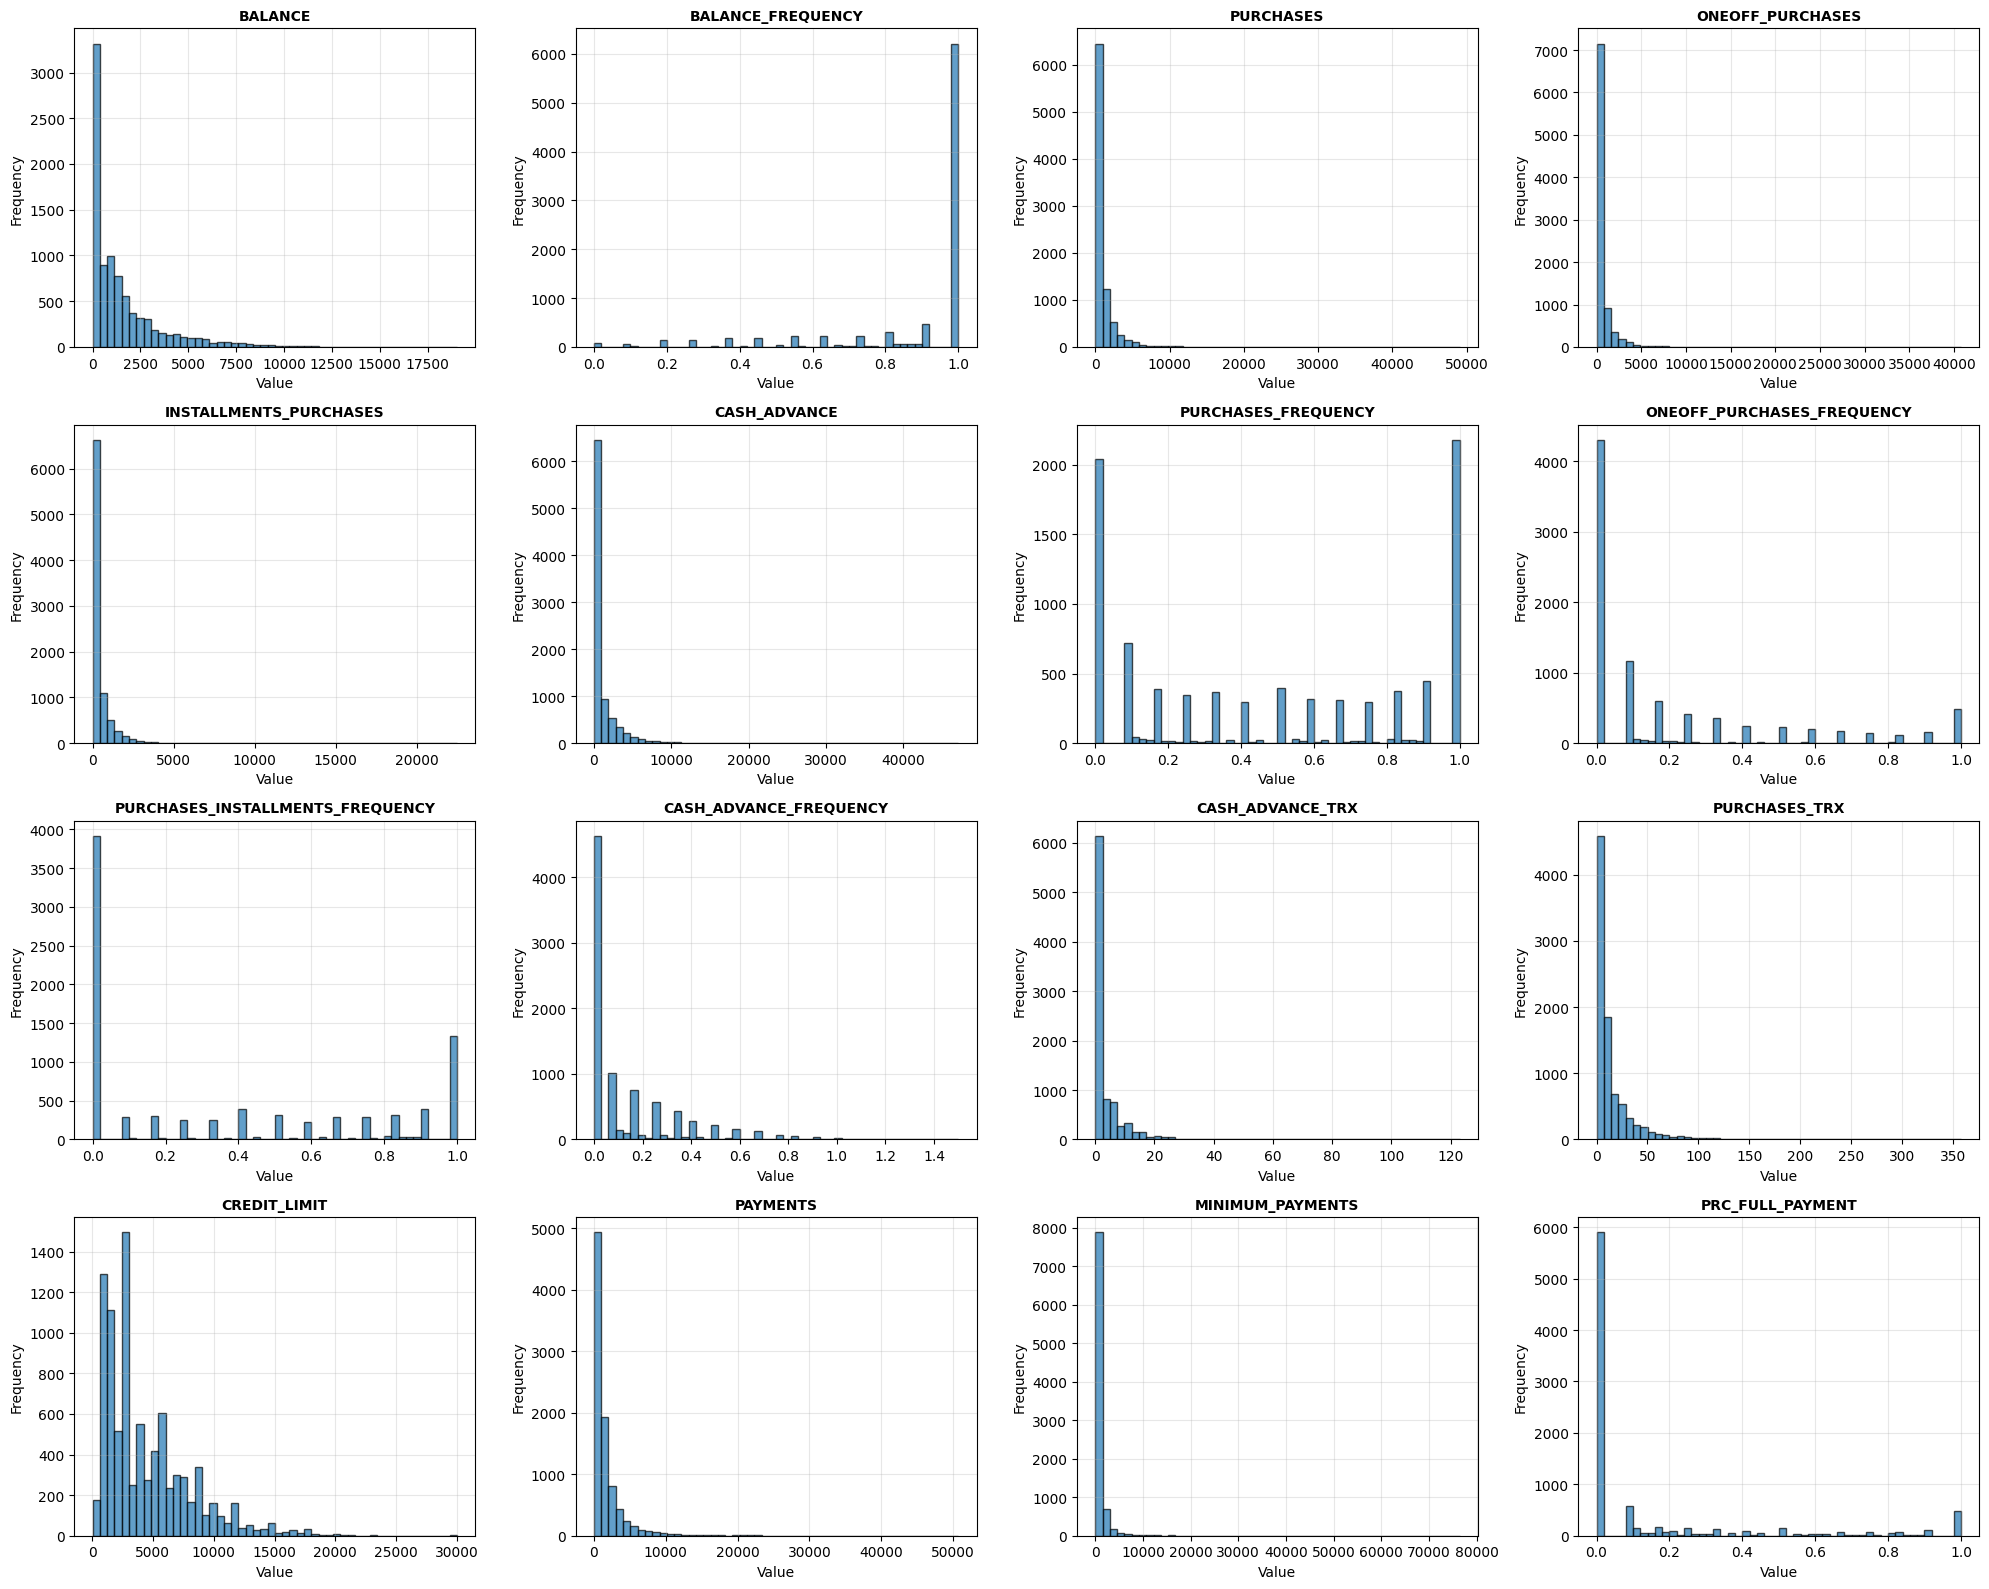

✓ Feature distributions saved as 'feature_distributions.png'


In [9]:
# Visualize distributions of key features
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()

for idx, col in enumerate(df_features.columns[:16]):
    axes[idx].hist(df_features[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature distributions saved as 'feature_distributions.png'")


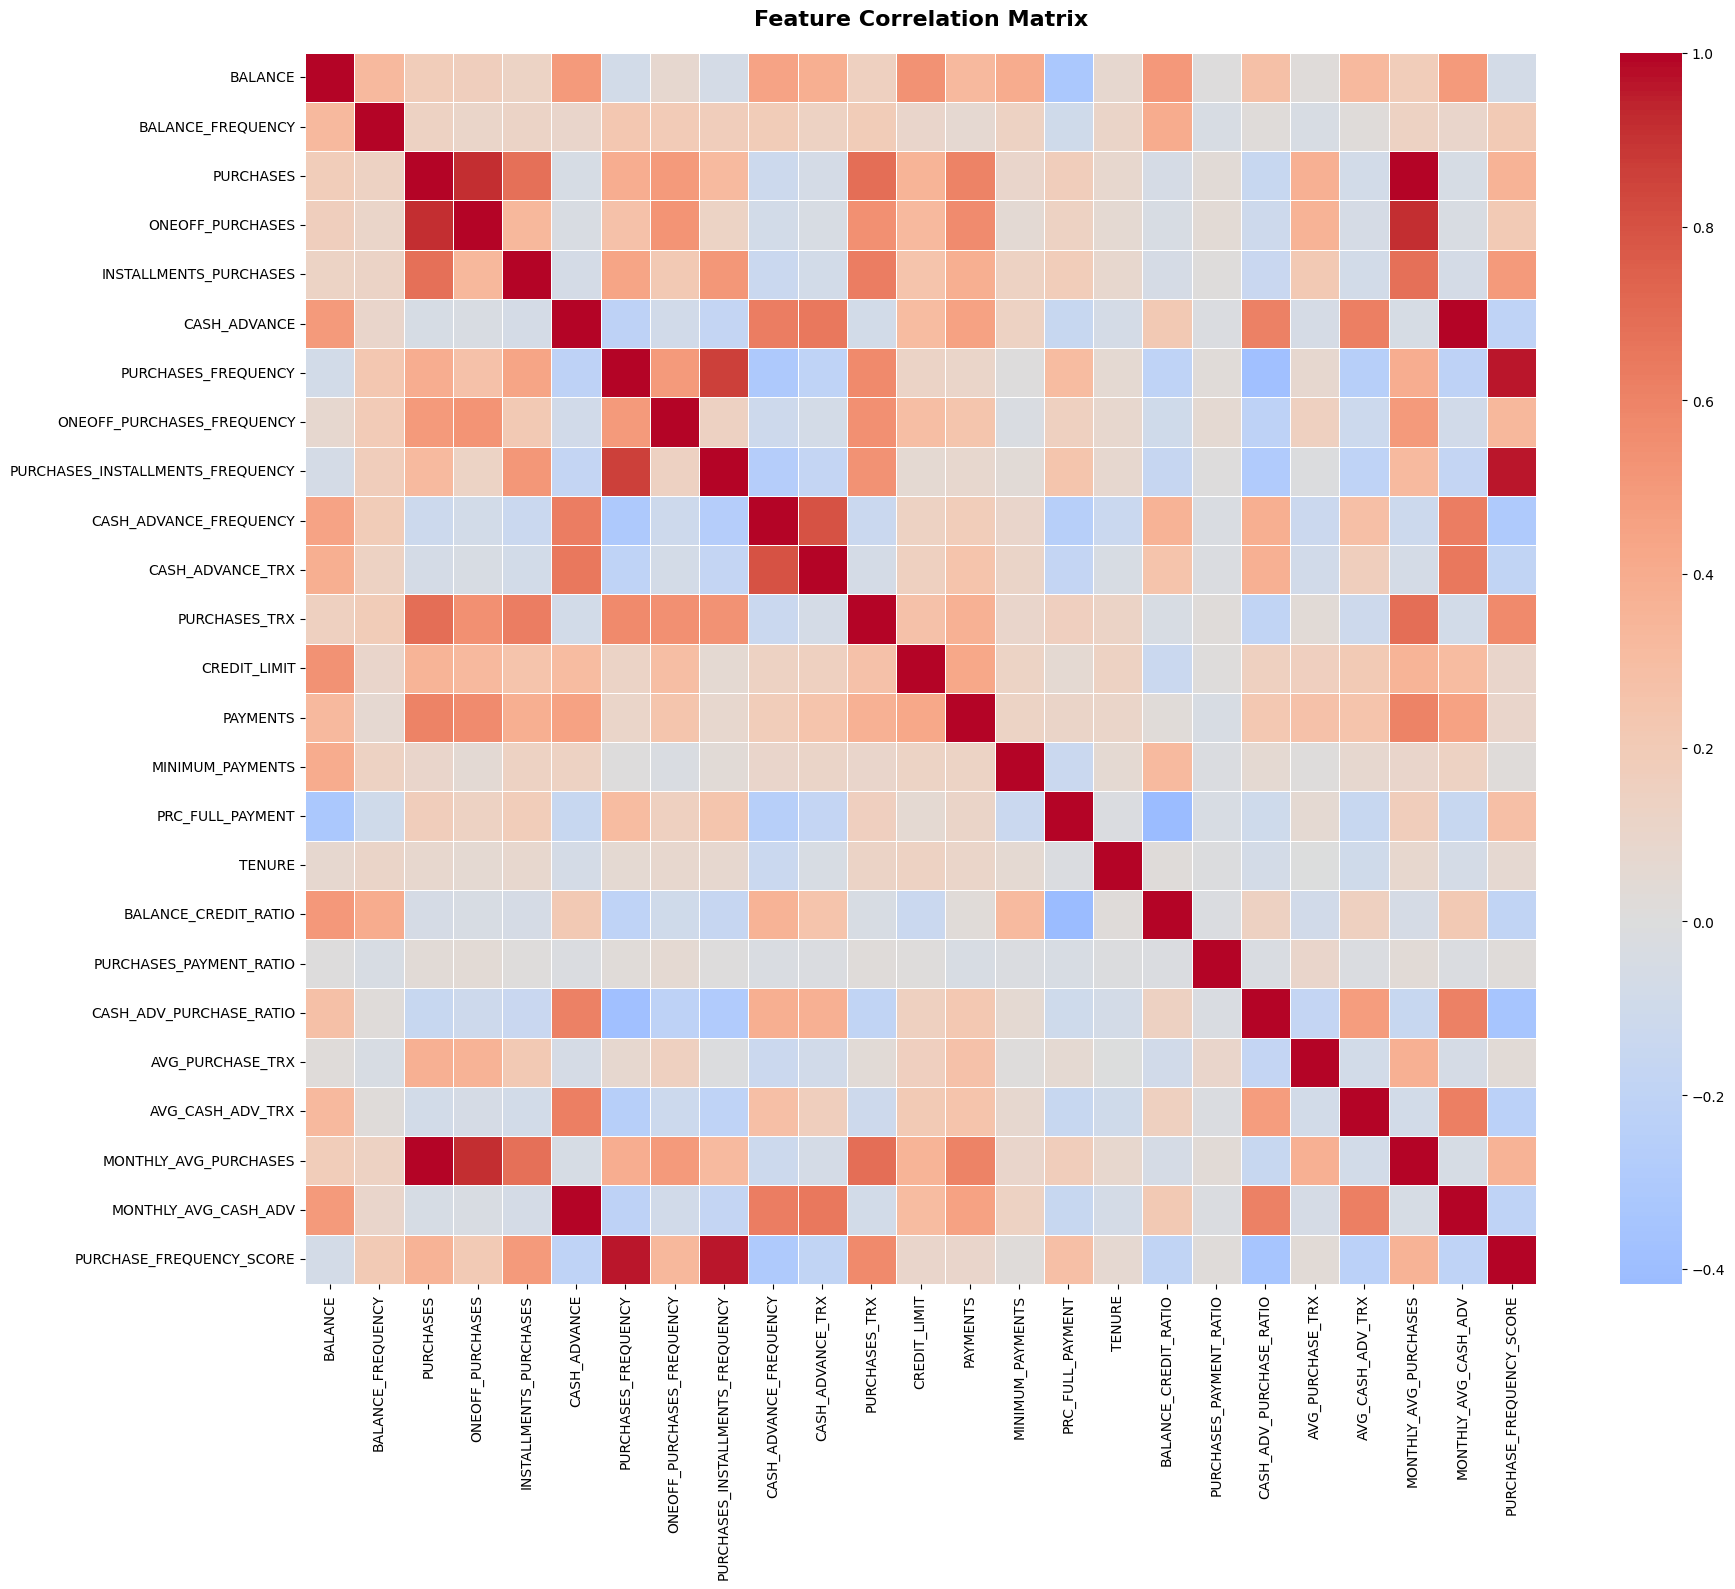

✓ Correlation matrix saved as 'correlation_matrix.png'

Highly correlated feature pairs (|r| > 0.9):
  PURCHASES <-> ONEOFF_PURCHASES: 0.917
  PURCHASES <-> MONTHLY_AVG_PURCHASES: 1.000
  ONEOFF_PURCHASES <-> MONTHLY_AVG_PURCHASES: 0.917
  CASH_ADVANCE <-> MONTHLY_AVG_CASH_ADV: 1.000
  PURCHASES_FREQUENCY <-> PURCHASE_FREQUENCY_SCORE: 0.965
  PURCHASES_INSTALLMENTS_FREQUENCY <-> PURCHASE_FREQUENCY_SCORE: 0.965


In [10]:
# Compute correlation matrix
correlation_matrix = df_features.corr()

# Visualize correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation matrix saved as 'correlation_matrix.png'")

# Identify highly correlated features (> 0.9)
high_corr = np.where(np.abs(correlation_matrix) > 0.9)
high_corr_list = [(correlation_matrix.index[x], correlation_matrix.columns[y], correlation_matrix.iloc[x, y]) 
                  for x, y in zip(*high_corr) if x != y and x < y]

print(f"\nHighly correlated feature pairs (|r| > 0.9):")
for feat1, feat2, corr in high_corr_list:
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")


In [11]:
# Standardize features using Z-score normalization
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)

# Convert back to DataFrame for convenience
df_scaled = pd.DataFrame(df_scaled, columns=df_features.columns)

print(f"Scaled data shape: {df_scaled.shape}")
print(f"\nScaled data statistics:")
print(df_scaled.describe())

# Save scaler for production use
joblib.dump(scaler, 'scaler_model.pkl')
print("\n✓ Scaler saved as 'scaler_model.pkl'")


Scaled data shape: (8950, 25)

Scaled data statistics:
            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count  8.950000e+03       8.950000e+03  8.950000e+03      8.950000e+03   
mean  -2.540488e-17       1.587805e-16  3.175610e-18     -6.033659e-17   
std    1.000056e+00       1.000056e+00  1.000056e+00      1.000056e+00   
min   -7.516398e-01      -3.703271e+00 -4.695519e-01     -3.569340e-01   
25%   -6.900078e-01       4.904486e-02 -4.510006e-01     -3.569340e-01   
50%   -3.320286e-01       5.180838e-01 -3.004541e-01     -3.340396e-01   
75%    2.352559e-01       5.180838e-01  5.004652e-02     -9.056763e-03   
max    8.397489e+00       5.180838e-01  2.248351e+01      2.420107e+01   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count            8.950000e+03  8.950000e+03         8.950000e+03   
mean             3.175610e-17 -6.351220e-18         9.328354e-17   
std              1.000056e+00  1.000056e+00         1.000056e+00   
min   

In [12]:
# Define Autoencoder architecture
input_dim = df_scaled.shape[1]
encoding_dims = [128, 64, 32, 16]  # Encoder layer dimensions
latent_dim = 8  # Compressed representation dimension

def build_autoencoder(input_dim, encoding_dims, latent_dim):
    """
    Build a deep autoencoder model
    """
    # Encoder
    input_layer = layers.Input(shape=(input_dim,))
    
    encoded = input_layer
    for dim in encoding_dims:
        encoded = layers.Dense(dim, activation='relu')(encoded)
        encoded = layers.BatchNormalization()(encoded)
        encoded = layers.Dropout(0.2)(encoded)
    
    # Latent space (bottleneck)
    latent = layers.Dense(latent_dim, activation='relu', name='latent_layer')(encoded)
    
    # Decoder (mirror architecture)
    decoded = latent
    for dim in reversed(encoding_dims):
        decoded = layers.Dense(dim, activation='relu')(decoded)
        decoded = layers.BatchNormalization()(decoded)
        decoded = layers.Dropout(0.2)(decoded)
    
    # Output layer
    output_layer = layers.Dense(input_dim, activation='linear')(decoded)
    
    # Complete autoencoder
    autoencoder = Model(inputs=input_layer, outputs=output_layer, name='autoencoder')
    
    # Encoder model for extracting latent features
    encoder = Model(inputs=input_layer, outputs=latent, name='encoder')
    
    return autoencoder, encoder

# Build models
autoencoder, encoder = build_autoencoder(input_dim, encoding_dims, latent_dim)

# Compile autoencoder
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("Autoencoder Architecture:")
print(autoencoder.summary())
print("\n" + "="*80)
print("Encoder Architecture:")
print(encoder.summary())


Autoencoder Architecture:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           25

 Total params: 30,593 (119.50 KB)

 Trainable params: 29,633 (115.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer (Dense)            │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,288 (59.72 KB)

 Trainable params: 14,808 (57.84 KB)

 Non-trainable params: 480 (1.88 KB)

None


In [13]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train autoencoder
history = autoencoder.fit(
    df_scaled, df_scaled,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✓ Autoencoder training completed")


Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 2.6121 - mae: 1.1652 - val_loss: 0.7271 - val_mae: 0.5849 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.6851 - mae: 0.9048 - val_loss: 0.7238 - val_mae: 0.5794 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3814 - mae: 0.7974 - val_loss: 0.7011 - val_mae: 0.5532 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2035 - mae: 0.7340 - val_loss: 0.6778 - val_mae: 0.5353 - learning_rate: 0.0010
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0802 - mae: 0.6799 - val_loss: 0.6317 - val_mae: 0.5059 - learning_rate: 0.0010
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9736 - mae: 0.6393 - val_loss: 0.5816 - val_mae: 0.4794 - learning_rate: 0.0010
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9389 - mae: 0.6127 - val_loss: 0.5196 - val_mae: 0.4409 - learning_rate: 0.0010
Epoch 8/100


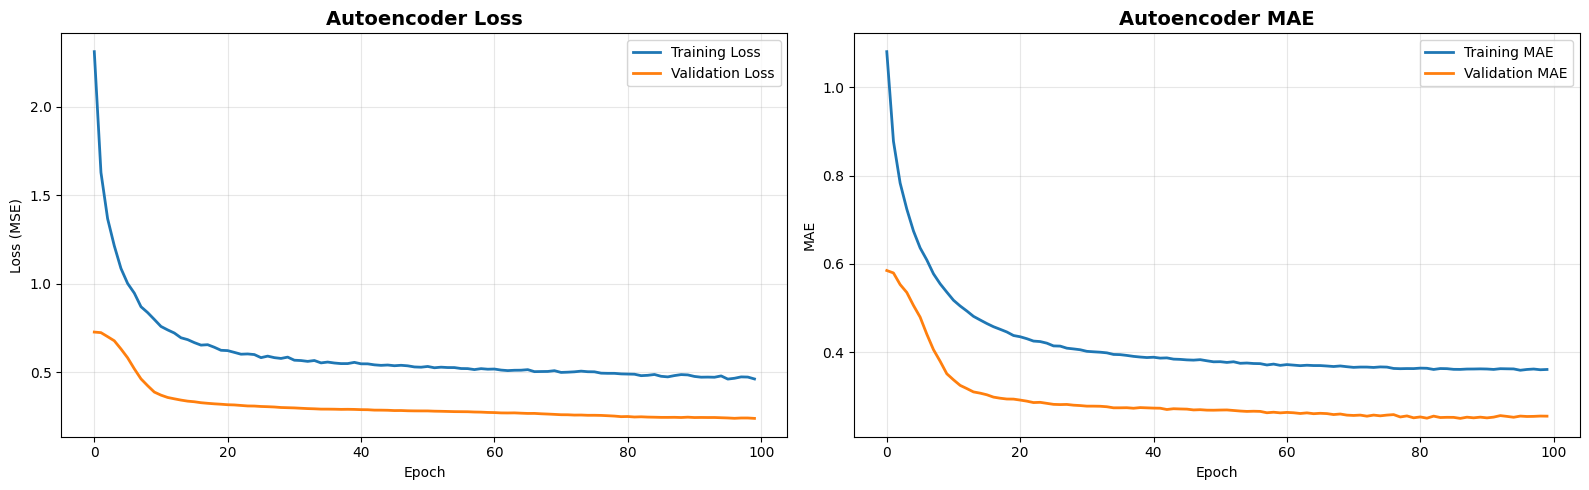

✓ Training history saved as 'autoencoder_training_history.png'


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Autoencoder Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Autoencoder MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('autoencoder_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history saved as 'autoencoder_training_history.png'")


In [15]:
# Extract latent representations using encoder
latent_features = encoder.predict(df_scaled)

print(f"Original feature dimensions: {df_scaled.shape[1]}")
print(f"Latent feature dimensions: {latent_features.shape[1]}")
print(f"Dimensionality reduction: {(1 - latent_features.shape[1]/df_scaled.shape[1])*100:.2f}%")

# Create DataFrame
latent_df = pd.DataFrame(
    latent_features,
    columns=[f'Latent_{i+1}' for i in range(latent_features.shape[1])]
)

print("\nLatent features sample:")
print(latent_df.head())


280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Original feature dimensions: 25
Latent feature dimensions: 8
Dimensionality reduction: 68.00%

Latent features sample:
   Latent_1  Latent_2  Latent_3  Latent_4  Latent_5  Latent_6  Latent_7  \
0  0.000000  0.000000  0.911924  0.000000  1.114207  1.219306  0.325308   
1  0.794342  0.000000  2.063859  0.000000  0.040115  0.478606  4.354018   
2  0.499529  0.678735  0.000000  0.470546  0.000000  0.079030  0.000000   
3  4.473452  0.000000  5.127191  0.000000  0.000000  0.000000  0.000000   
4  0.000000  0.333221  0.833739  0.000000  0.611608  1.667158  0.164837   

   Latent_8  
0  0.000000  
1  2.486364  
2  0.257119  
3  0.000000  
4  0.000000  


K=2: Inertia=66820.08, Silhouette Score=0.7979
K=3: Inertia=55456.44, Silhouette Score=0.5657
K=4: Inertia=47506.01, Silhouette Score=0.2546
K=5: Inertia=40189.89, Silhouette Score=0.2668
K=6: Inertia=35958.70, Silhouette Score=0.2708
K=7: Inertia=32346.96, Silhouette Score=0.2912
K=8: Inertia=29934.55, Silhouette Score=0.2939
K=9: Inertia=27936.61, Silhouette Score=0.2910
K=10: Inertia=25866.59, Silhouette Score=0.2875


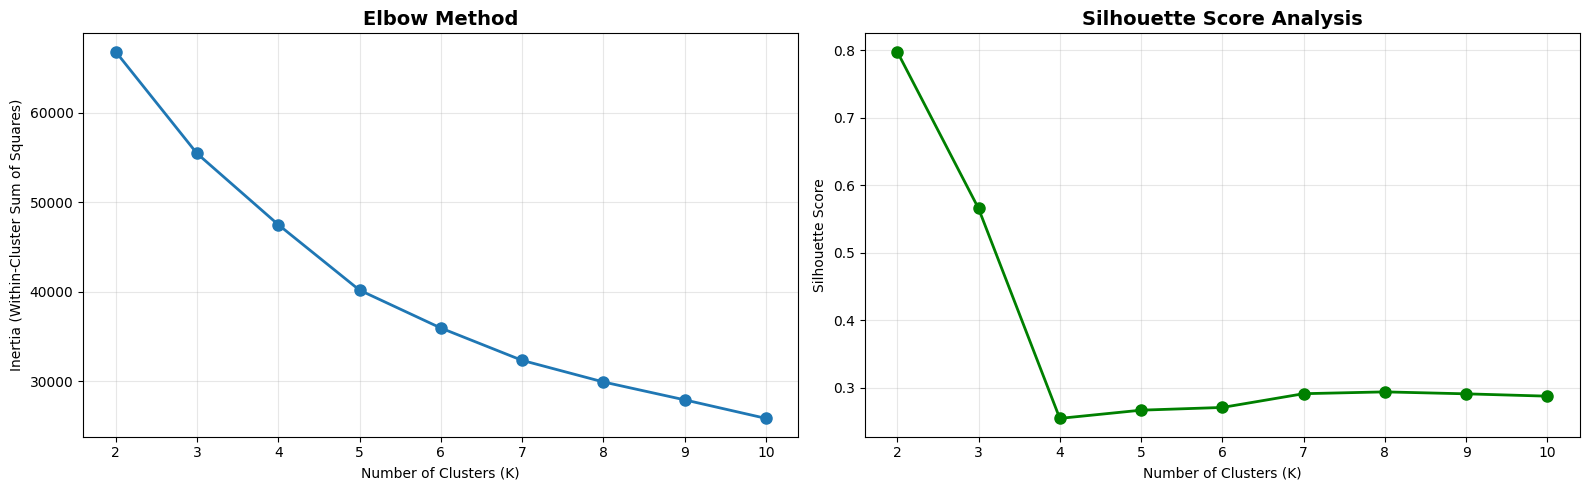


✓ Optimal number of clusters based on Silhouette Score: K=2
  Max Silhouette Score: 0.7979


In [16]:
# Elbow Method and Silhouette Analysis
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(latent_features)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(latent_features, labels))
    
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={silhouette_scores[-1]:.4f}")

# Visualize optimal k
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow plot
axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_clusters_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Find optimal k (highest silhouette score)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal number of clusters based on Silhouette Score: K={optimal_k}")
print(f"  Max Silhouette Score: {max(silhouette_scores):.4f}")


In [17]:
# Apply K-Means with optimal k
optimal_k = 5  # Based on analysis or domain knowledge

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20,
    max_iter=300
)

cluster_labels = kmeans_final.fit_predict(latent_features)

# Add cluster labels to original data
df['Cluster'] = cluster_labels
df_scaled['Cluster'] = cluster_labels

print(f"Clustering completed with K={optimal_k}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Calculate clustering metrics
silhouette_avg = silhouette_score(latent_features, cluster_labels)
calinski_score = calinski_harabasz_score(latent_features, cluster_labels)
davies_bouldin = davies_bouldin_score(latent_features, cluster_labels)

print(f"\nClustering Evaluation Metrics:")
print(f"  Silhouette Score: {silhouette_avg:.4f}")
print(f"  Calinski-Harabasz Score: {calinski_score:.2f}")
print(f"  Davies-Bouldin Index: {davies_bouldin:.4f}")

# Save K-Means model
joblib.dump(kmeans_final, 'kmeans_model.pkl')
print("\n✓ K-Means model saved as 'kmeans_model.pkl'")


Clustering completed with K=5

Cluster distribution:
Cluster
0    4618
1      28
2     349
3    3655
4     300
Name: count, dtype: int64

Clustering Evaluation Metrics:
  Silhouette Score: 0.2668
  Calinski-Harabasz Score: 2692.82
  Davies-Bouldin Index: 1.1625

✓ K-Means model saved as 'kmeans_model.pkl'


Cluster Profiles (Mean values):
             BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                   
0        1255.522184           0.798361    267.779417        199.498922   
1        5647.590691           0.954221  25592.046786      18777.016071   
2        5480.448441           0.939837    469.385530        312.454613   
3        1378.872225           0.961479   1314.187601        680.071844   
4        3644.870776           0.986061   6861.097900       4201.875833   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                     68.459448    804.195959             0.179040   
1                   6815.030714    919.116626             0.904167   
2                    157.122751   8240.538228             0.192914   
3                    634.442235    528.401410             0.871866   
4                   26

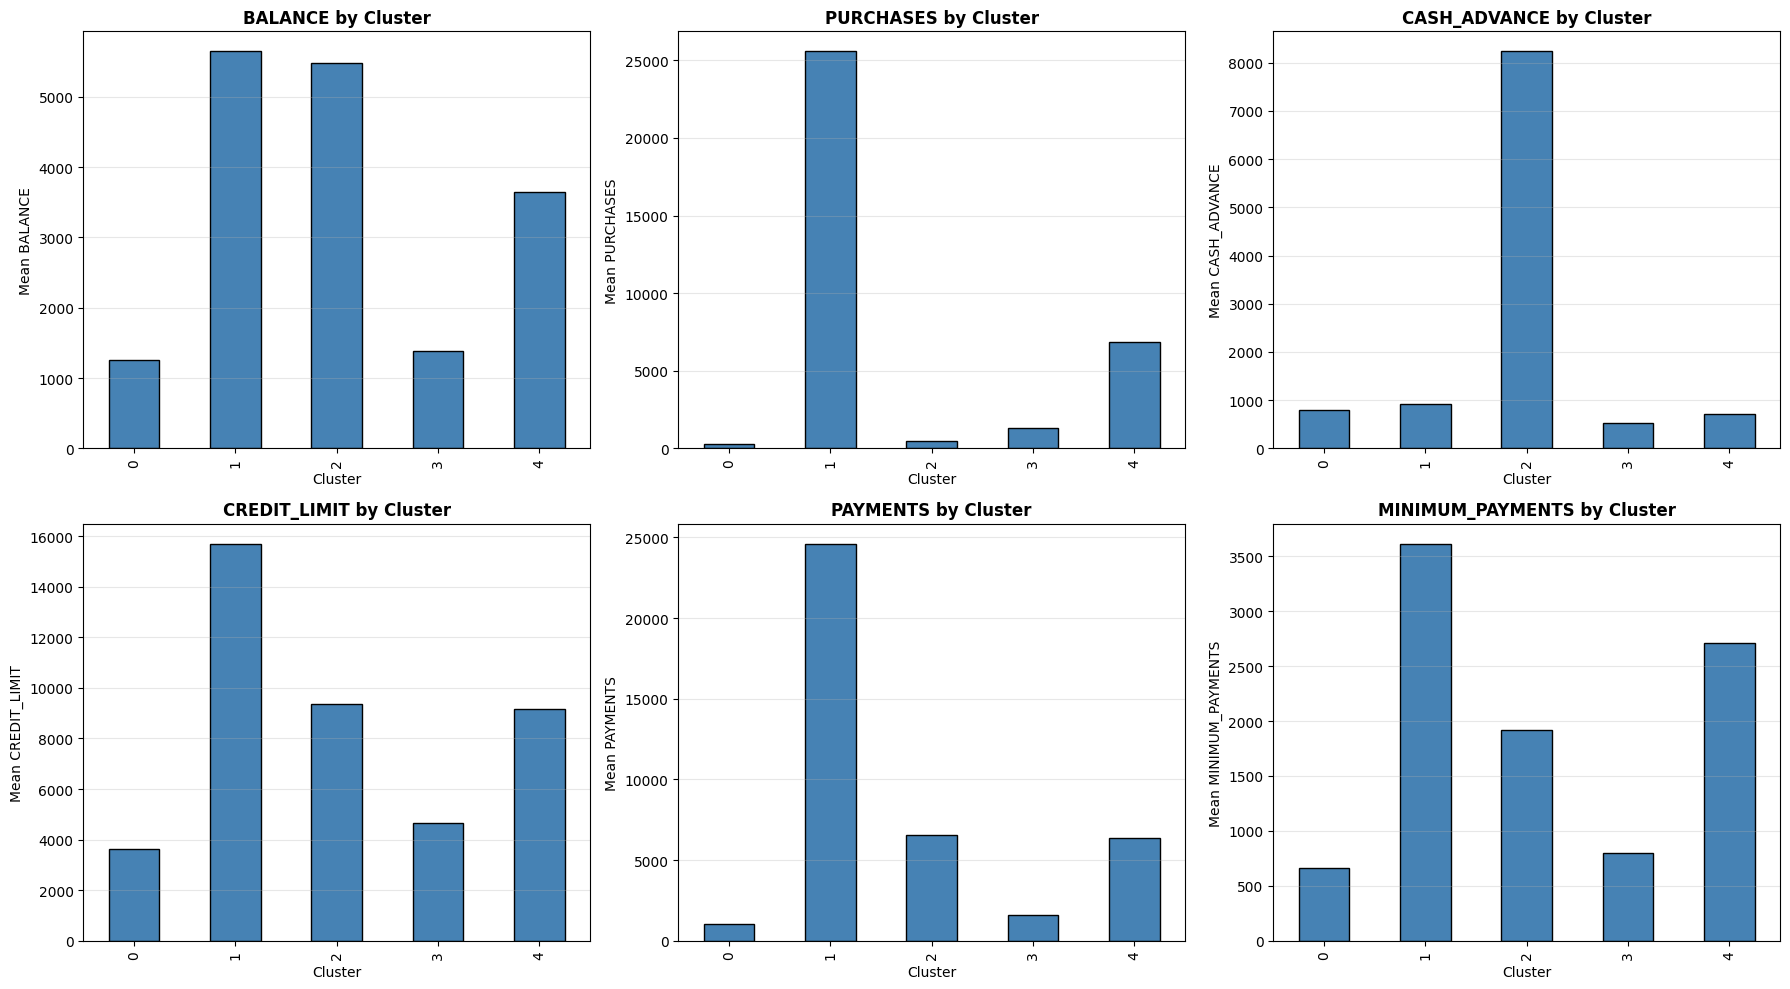

✓ Cluster profiles visualization saved


In [19]:
# Analyze cluster characteristics
# Compute cluster profiles using the numeric feature set (including engineered features)
# Join cluster labels from df to ensure no object columns (like CUST_ID) are included
cluster_profiles = pd.concat([df_features, df['Cluster']], axis=1).groupby('Cluster').mean()

print("Cluster Profiles (Mean values):")
print(cluster_profiles)

# Save cluster profiles
cluster_profiles.to_csv('cluster_profiles.csv')
print("\n✓ Cluster profiles saved as 'cluster_profiles.csv'")

# Visualize key features by cluster
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 
                'PAYMENTS', 'MINIMUM_PAYMENTS']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    cluster_profiles[feature].plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(f'Mean {feature}')
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cluster_profiles_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cluster profiles visualization saved")


In [20]:
# Assign interpretable labels based on cluster characteristics
def assign_cluster_labels(df, cluster_col='Cluster'):
    """
    Assign meaningful labels to clusters based on spending behavior
    """
    labels_map = {}
    
    for cluster in df[cluster_col].unique():
        cluster_data = df[df[cluster_col] == cluster]
        
        avg_balance = cluster_data['BALANCE'].mean()
        avg_purchases = cluster_data['PURCHASES'].mean()
        avg_cash_adv = cluster_data['CASH_ADVANCE'].mean()
        avg_payments = cluster_data['PAYMENTS'].mean()
        purchase_freq = cluster_data['PURCHASES_FREQUENCY'].mean()
        
        # Decision logic for labeling
        if avg_purchases > df['PURCHASES'].quantile(0.75):
            if purchase_freq > 0.8:
                label = "High Spender - Frequent Buyer"
            else:
                label = "High Spender - Occasional Buyer"
        elif avg_cash_adv > df['CASH_ADVANCE'].quantile(0.75):
            label = "Cash Advance User"
        elif avg_balance > df['BALANCE'].quantile(0.75):
            label = "High Balance Holder"
        elif avg_payments > df['PAYMENTS'].quantile(0.75):
            label = "Diligent Payer"
        else:
            label = "Low Activity User"
        
        labels_map[cluster] = label
    
    return labels_map

# Assign labels
cluster_labels_map = assign_cluster_labels(df)
df['Cluster_Label'] = df['Cluster'].map(cluster_labels_map)

print("Cluster Label Mapping:")
for cluster, label in cluster_labels_map.items():
    count = len(df[df['Cluster'] == cluster])
    print(f"  Cluster {cluster}: {label} ({count} customers)")

# Save mapping
with open('cluster_labels_map.pkl', 'wb') as f:
    pickle.dump(cluster_labels_map, f)

print("\n✓ Cluster labels map saved as 'cluster_labels_map.pkl'")


Cluster Label Mapping:
  Cluster 0: Low Activity User (4618 customers)
  Cluster 2: Cash Advance User (349 customers)
  Cluster 3: High Spender - Frequent Buyer (3655 customers)
  Cluster 4: High Spender - Frequent Buyer (300 customers)
  Cluster 1: High Spender - Frequent Buyer (28 customers)

✓ Cluster labels map saved as 'cluster_labels_map.pkl'


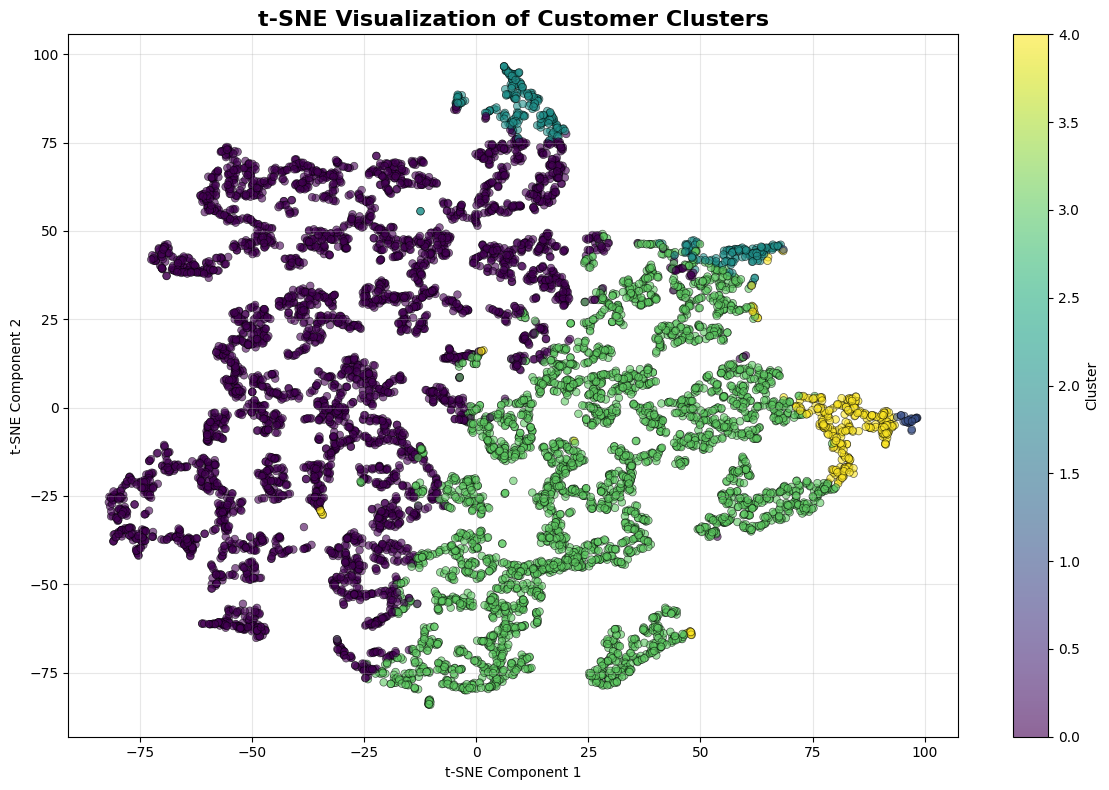

✓ t-SNE visualization saved as 'tsne_clusters.png'


In [22]:
import inspect

# t-SNE visualization
# Create TSNE with compatible parameter name (n_iter vs max_iter)

sig = inspect.signature(TSNE)
if 'n_iter' in sig.parameters:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
elif 'max_iter' in sig.parameters:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
else:
    # fallback to defaults if neither parameter is present
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(latent_features)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    latent_tsne[:, 0], 
    latent_tsne[:, 1], 
    c=cluster_labels, 
    cmap='viridis', 
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.title('t-SNE Visualization of Customer Clusters', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ t-SNE visualization saved as 'tsne_clusters.png'")


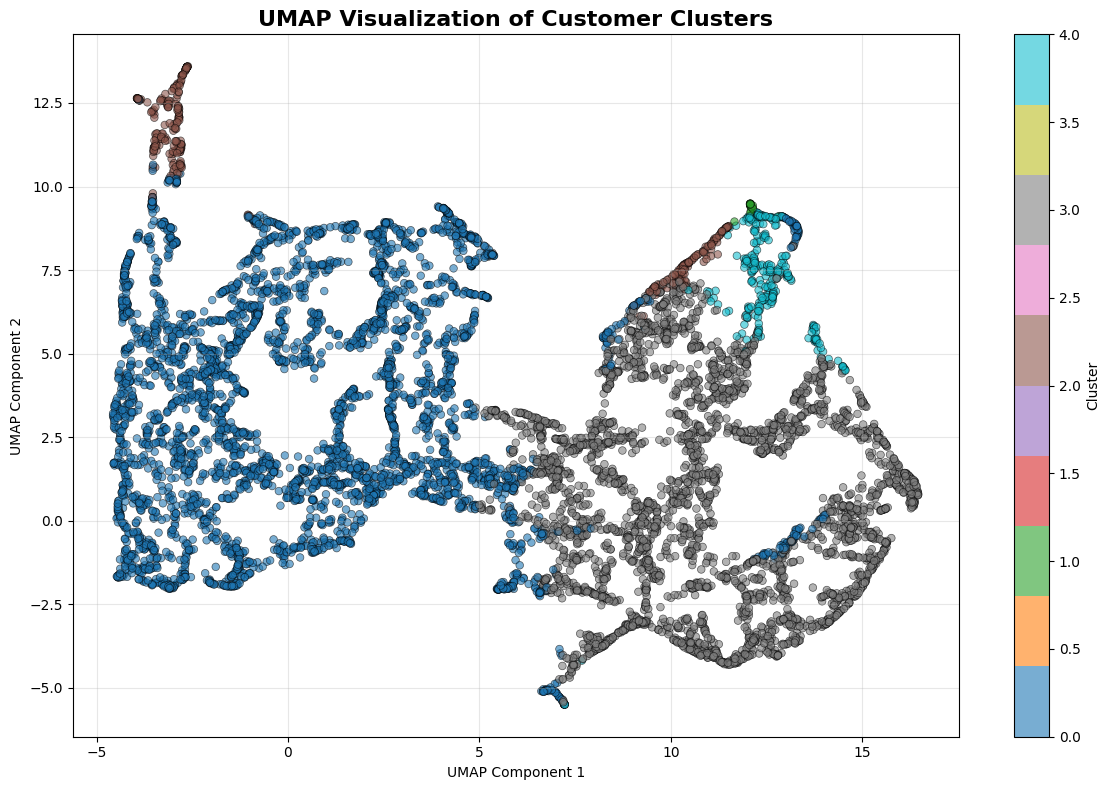

✓ UMAP visualization saved as 'umap_clusters.png'


In [23]:
# UMAP visualization (better preserves global structure)
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
latent_umap = reducer.fit_transform(latent_features)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    latent_umap[:, 0], 
    latent_umap[:, 1], 
    c=cluster_labels, 
    cmap='tab10', 
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.title('UMAP Visualization of Customer Clusters', fontsize=16, fontweight='bold')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('umap_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ UMAP visualization saved as 'umap_clusters.png'")


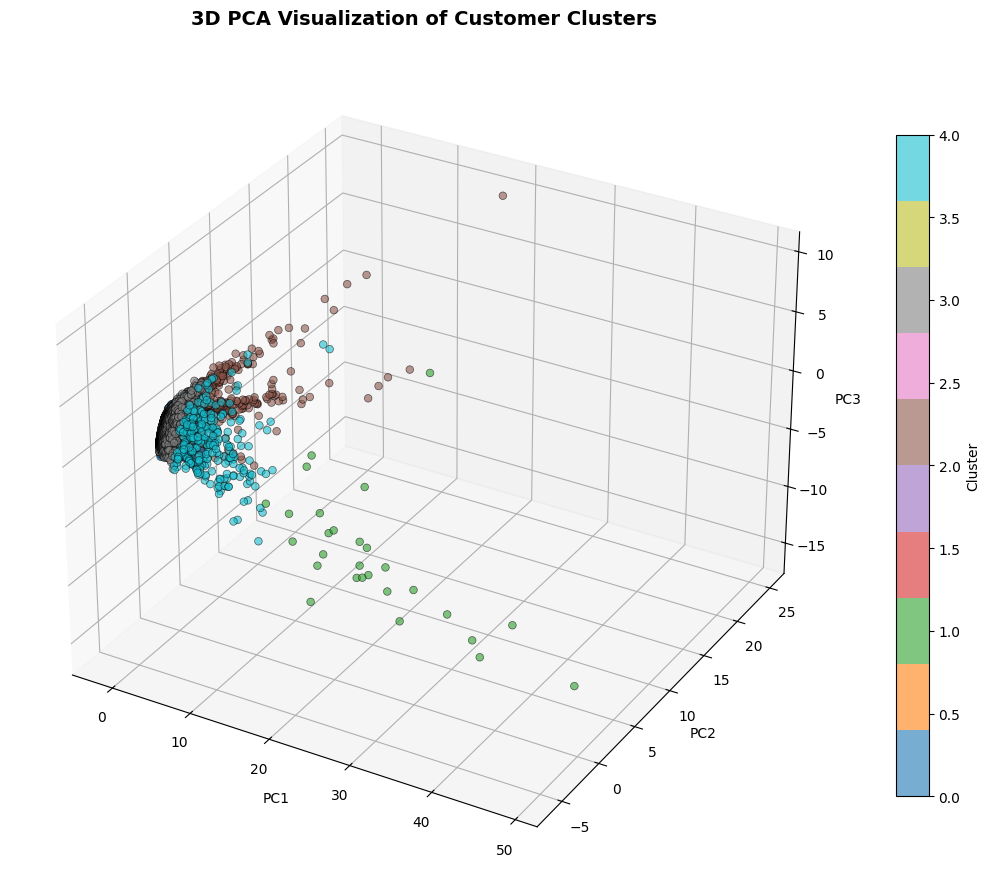

✓ 3D PCA visualization saved as 'pca_3d_clusters.png'


In [24]:
# PCA for 3D visualization
pca_3d = PCA(n_components=3)
latent_pca_3d = pca_3d.fit_transform(latent_features)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    latent_pca_3d[:, 0],
    latent_pca_3d[:, 1],
    latent_pca_3d[:, 2],
    c=cluster_labels,
    cmap='tab10',
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Visualization of Customer Clusters', fontsize=14, fontweight='bold', pad=20)
plt.colorbar(scatter, label='Cluster', shrink=0.8)
plt.tight_layout()
plt.savefig('pca_3d_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 3D PCA visualization saved as 'pca_3d_clusters.png'")


In [25]:
# Save autoencoder and encoder models
autoencoder.save('autoencoder_model.h5')
encoder.save('encoder_model.h5')

print("✓ Autoencoder saved as 'autoencoder_model.h5'")
print("✓ Encoder saved as 'encoder_model.h5'")

# Save final clustered dataset
df.to_csv('clustered_customers.csv', index=False)
print("✓ Clustered customer data saved as 'clustered_customers.csv'")

# Create model metadata
model_metadata = {
    'input_dim': input_dim,
    'encoding_dims': encoding_dims,
    'latent_dim': latent_dim,
    'optimal_k': optimal_k,
    'silhouette_score': silhouette_avg,
    'calinski_harabasz_score': calinski_score,
    'davies_bouldin_index': davies_bouldin,
    'cluster_labels_map': cluster_labels_map,
    'feature_columns': df_features.columns.tolist()
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print("✓ Model metadata saved as 'model_metadata.pkl'")

print("\n" + "="*80)
print("MODEL PIPELINE SAVED SUCCESSFULLY!")
print("="*80)
print("\nSaved files:")
print("  1. imputer_model.pkl - Missing value imputer")
print("  2. scaler_model.pkl - Feature scaler")
print("  3. autoencoder_model.h5 - Complete autoencoder")
print("  4. encoder_model.h5 - Encoder for latent features")
print("  5. kmeans_model.pkl - K-Means clustering model")
print("  6. cluster_labels_map.pkl - Cluster label mapping")
print("  7. model_metadata.pkl - Model configuration metadata")
print("  8. clustered_customers.csv - Final clustered dataset")
print("  9. cluster_profiles.csv - Cluster characteristics")


✓ Autoencoder saved as 'autoencoder_model.h5'
✓ Encoder saved as 'encoder_model.h5'
✓ Clustered customer data saved as 'clustered_customers.csv'
✓ Model metadata saved as 'model_metadata.pkl'

MODEL PIPELINE SAVED SUCCESSFULLY!

Saved files:
  1. imputer_model.pkl - Missing value imputer
  2. scaler_model.pkl - Feature scaler
  3. autoencoder_model.h5 - Complete autoencoder
  4. encoder_model.h5 - Encoder for latent features
  5. kmeans_model.pkl - K-Means clustering model
  6. cluster_labels_map.pkl - Cluster label mapping
  7. model_metadata.pkl - Model configuration metadata
  8. clustered_customers.csv - Final clustered dataset
  9. cluster_profiles.csv - Cluster characteristics


In [26]:
def predict_cluster_for_new_customer(new_data, return_proba=False):
    """
    Predict cluster for new customer data
    
    Parameters:
    -----------
    new_data : dict or DataFrame
        Customer transaction data
    return_proba : bool
        If True, returns cluster probabilities
        
    Returns:
    --------
    cluster_id : int
        Assigned cluster
    cluster_label : str
        Interpretable cluster label
    """
    # Load saved models
    imputer = joblib.load('imputer_model.pkl')
    scaler = joblib.load('scaler_model.pkl')
    encoder = keras.models.load_model('encoder_model.h5')
    kmeans = joblib.load('kmeans_model.pkl')
    
    with open('cluster_labels_map.pkl', 'rb') as f:
        labels_map = pickle.load(f)
    
    with open('model_metadata.pkl', 'rb') as f:
        metadata = pickle.load(f)
    
    # Convert to DataFrame if dict
    if isinstance(new_data, dict):
        new_data = pd.DataFrame([new_data])
    
    # Drop CUST_ID if present
    if 'CUST_ID' in new_data.columns:
        new_data = new_data.drop('CUST_ID', axis=1)
    
    # Impute missing values
    new_data_imputed = pd.DataFrame(
        imputer.transform(new_data),
        columns=new_data.columns
    )
    
    # Feature engineering (same as training)
    new_features = new_data_imputed.copy()
    new_features['BALANCE_CREDIT_RATIO'] = new_features['BALANCE'] / (new_features['CREDIT_LIMIT'] + 1)
    new_features['PURCHASES_PAYMENT_RATIO'] = new_features['PURCHASES'] / (new_features['PAYMENTS'] + 1)
    new_features['CASH_ADV_PURCHASE_RATIO'] = new_features['CASH_ADVANCE'] / (new_features['PURCHASES'] + 1)
    new_features['AVG_PURCHASE_TRX'] = new_features['PURCHASES'] / (new_features['PURCHASES_TRX'] + 1)
    new_features['AVG_CASH_ADV_TRX'] = new_features['CASH_ADVANCE'] / (new_features['CASH_ADVANCE_TRX'] + 1)
    new_features['MONTHLY_AVG_PURCHASES'] = new_features['PURCHASES'] / 12
    new_features['MONTHLY_AVG_CASH_ADV'] = new_features['CASH_ADVANCE'] / 12
    new_features['PURCHASE_FREQUENCY_SCORE'] = (
        new_features['PURCHASES_FREQUENCY'] + 
        new_features['PURCHASES_INSTALLMENTS_FREQUENCY']
    ) / 2
    new_features.replace([np.inf, -np.inf], 0, inplace=True)
    
    # Scale features
    new_scaled = scaler.transform(new_features)
    
    # Extract latent features
    new_latent = encoder.predict(new_scaled, verbose=0)
    
    # Predict cluster
    cluster_id = kmeans.predict(new_latent)[0]
    cluster_label = labels_map[cluster_id]
    
    if return_proba:
        # Calculate distances to all cluster centers
        distances = kmeans.transform(new_latent)[0]
        # Convert to probabilities (inverse distance)
        proba = 1 / (distances + 1e-10)
        proba = proba / proba.sum()
        return cluster_id, cluster_label, proba
    
    return cluster_id, cluster_label

# Test inference function
print("Testing inference pipeline...")
print("\nExample prediction:")

# Create sample customer data
sample_customer = df.iloc[0:1].drop(['Cluster', 'Cluster_Label'], axis=1).to_dict('records')[0]
cluster_id, cluster_label = predict_cluster_for_new_customer(sample_customer)

print(f"  Predicted Cluster: {cluster_id}")
print(f"  Cluster Label: {cluster_label}")

print("\n✓ Inference pipeline tested successfully!")


Testing inference pipeline...

Example prediction:
  Predicted Cluster: 0
  Cluster Label: Low Activity User

✓ Inference pipeline tested successfully!


In [27]:
# Generate comprehensive model summary
print("="*80)
print(" "*20 + "MODEL SUMMARY REPORT")
print("="*80)

print(f"\n{'Dataset Information':-^80}")
print(f"  Total Customers: {len(df):,}")
print(f"  Original Features: {input_dim}")
print(f"  Engineered Features: {df_features.shape[1]}")
print(f"  Missing Value Imputation: Median strategy")

print(f"\n{'Autoencoder Architecture':-^80}")
print(f"  Input Dimension: {input_dim}")
print(f"  Encoding Layers: {encoding_dims}")
print(f"  Latent Dimension: {latent_dim}")
print(f"  Compression Ratio: {(1 - latent_dim/input_dim)*100:.2f}%")
print(f"  Training Epochs: {len(history.history['loss'])}")
print(f"  Final Training Loss: {history.history['loss'][-1]:.6f}")
print(f"  Final Validation Loss: {history.history['val_loss'][-1]:.6f}")

print(f"\n{'Clustering Results':-^80}")
print(f"  Algorithm: K-Means")
print(f"  Number of Clusters: {optimal_k}")
print(f"  Silhouette Score: {silhouette_avg:.4f}")
print(f"  Calinski-Harabasz Score: {calinski_score:.2f}")
print(f"  Davies-Bouldin Index: {davies_bouldin:.4f}")

print(f"\n{'Cluster Distribution':-^80}")
for cluster, label in cluster_labels_map.items():
    count = len(df[df['Cluster'] == cluster])
    percentage = (count / len(df)) * 100
    print(f"  Cluster {cluster} ({label}): {count:,} customers ({percentage:.2f}%)")

print(f"\n{'Saved Artifacts':-^80}")
artifacts = [
    'imputer_model.pkl', 'scaler_model.pkl', 'autoencoder_model.h5',
    'encoder_model.h5', 'kmeans_model.pkl', 'cluster_labels_map.pkl',
    'model_metadata.pkl', 'clustered_customers.csv', 'cluster_profiles.csv'
]
for artifact in artifacts:
    print(f"  ✓ {artifact}")

print("\n" + "="*80)
print(" "*25 + "MODELING COMPLETE!")
print("="*80)


                    MODEL SUMMARY REPORT

------------------------------Dataset Information-------------------------------
  Total Customers: 8,950
  Original Features: 25
  Engineered Features: 25
  Missing Value Imputation: Median strategy

----------------------------Autoencoder Architecture----------------------------
  Input Dimension: 25
  Encoding Layers: [128, 64, 32, 16]
  Latent Dimension: 8
  Compression Ratio: 68.00%
  Training Epochs: 100
  Final Training Loss: 0.462102
  Final Validation Loss: 0.239366

-------------------------------Clustering Results-------------------------------
  Algorithm: K-Means
  Number of Clusters: 5
  Silhouette Score: 0.2668
  Calinski-Harabasz Score: 2692.82
  Davies-Bouldin Index: 1.1625

------------------------------Cluster Distribution------------------------------
  Cluster 0 (Low Activity User): 4,618 customers (51.60%)
  Cluster 2 (Cash Advance User): 349 customers (3.90%)
  Cluster 3 (High Spender - Frequent Buyer): 3,655 customers (4